# Text Preprocessing and Sentiment Analysis Demonstration In Python

##### Using Starbucks Review Dataset

### Background :
This dataset contains a comprehensive collection of consumer reviews and ratings for Starbucks, a renowned coffeehouse chain. The data was collected through web scraping and includes textual reviews, star ratings, location information, and image links from multiple pages on the ConsumerAffairs website. It offers valuable insights into customer sentiment and feedback about Starbucks locations.

### Objective :
To analyze customer sentiment in online reviews of Starbucks locations and products.

### Import Libraries

In [1]:
import pandas as pd
import seaborn as sns

import nltk
#nltk.download('vader_lexicon')
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

import warnings
warnings.filterwarnings('ignore')

### Import Data

In [2]:
data = pd.read_csv("reviews_data.csv")
data.head()

,name,location,Date,Rating,Review
0,Helen,"Wichita Falls, TX","Sept 13, 2023",5,Amber and LaDonna at the Starbucks on Southwes...
1,Courtney,"Apopka, FL","July 16, 2023",5,** at the Starbucks by the fire station on 436...
2,Daynelle,"Cranberry Twp, PA","July 5, 2023",5,I just wanted to go out of my way to recognize...
3,Taylor,"Seattle, WA","May 26, 2023",5,Me and my friend were at Starbucks and my card...
4,Tenessa,"Gresham, OR","Jan 22, 2023",5,I’m on this kick of drinking 5 cups of warm wa...


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      812 non-null    object
 1   location  812 non-null    object
 2   Date      812 non-null    object
 3   Rating    812 non-null    int64 
 4   Review    812 non-null    object
dtypes: int64(1), object(4)
memory usage: 31.8+ KB


### Analysis Steps:
1)  Text Pre-processing
2)  Creation of WordCloud
3)  Sentiment Analysis - Overall and By Year

### 1) Text Pre-processing

**NOTE:**
We are using TWO different preprocessing pipelines based on the use-case:

**1. WordCloud Preprocessing:**
This pipeline applies aggressive cleaning including stopword removal,tokenization, and lemmatization. The goal is to extract the most meaningful and frequent words for visualization, not to preserve sentence structure or sentiment context.

**2. VADER Preprocessing:**
This pipeline uses minimal cleaning because VADER is a rule-based sentiment analyzer that relies on natural language structure, punctuation, and negations (e.g., "not good").

Hence, we avoid English stopword removal, tokenization, lemmatization and heavy preprocessing to ensure accurate sentiment scoring.

>In summary:
WordCloud → heavy preprocessing (clean & compress text)
VADER → light preprocessing (preserve meaning & context)

In [4]:
#Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Initialize SentimentIntensityAnalyzer for sentiment analysis
sid = SentimentIntensityAnalyzer()


# Wordcloud Preprocessing 
def preprocess_text_wordcloud(text):
    # Lowercase the text
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Get a set of NLTK English stopwords
    stop_words = set(stopwords.words('english'))
    
    # Remove English stopwords like: i, me, our and, the, is, etc.
    tokens = [word for word in tokens if word not in stop_words]
    # print(text_without_stopwords)
    
    # Remove Obvious words
    custom_stop_words = set(["drink","drinks","starbucks", "coffee","store"])

    tokens = [word for word in tokens if word not in custom_stop_words]
    
    # Lemmatization 
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join the tokens back into a sentence
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text

# VADER Preprocessing
def preprocess_text_vader(text):
    # Lowercase
    text = text.lower()
    
    # Light cleaning (keep sentiment cues like ! ?)
    text = re.sub(r'[^a-zA-Z\s!?]', '', text)
    
    # Remove domain-specific words only
    custom_stop_words = {"drink","drinks","starbucks","coffee","store"}
    
    tokens = text.split()  # simple split is enough
    tokens = [word for word in tokens if word not in custom_stop_words]
    
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text

# Apply preprocessing to the "Review" column
data['Cleaned_Review_wordcloud'] = data['Review'].apply(preprocess_text_wordcloud)
data['Cleaned_Review'] = data['Review'].apply(preprocess_text_vader)

**Note:** 
- Removing stopwords and obvious words can generally improve the performance of sentiment analysis by focusing the model on the most informative words. However, it’s crucial to carefully curate your stopword list to ensure it doesn’t exclude sentiment-carrying words.  


- **Lemmatization** is preferred over stemming to preserve meaningful word forms, ensuring better accuracy in sentiment analysis (VADER).

#### Checking "Reviews" before and after cleaning

In [5]:
data['Review'][0]

'Amber and LaDonna at the Starbucks on Southwest Parkway are always so warm and welcoming. There is always a smile in their voice when they greet you at the drive-thru. And their customer service is always spot-on, they always get my order right and with a smile. I would actually give them more than 5 stars if they were available.'

In [6]:
data['Cleaned_Review'][0] #preprocess_text_vader()

'amber and ladonna at the on southwest parkway are always so warm and welcoming there is always a smile in their voice when they greet you at the drivethru and their customer service is always spoton they always get my order right and with a smile i would actually give them more than stars if they were available'

In [7]:
data['Cleaned_Review_wordcloud'][0] #preprocess_text_wordcloud()

'amber ladonna southwest parkway always warm welcoming always smile voice greet drivethru customer service always spoton always get order right smile would actually give star available'

### 2) Creating Word Clouds from Text and Visualizing Reviews
Based on the "Rating" column we will plot two Word clouds as follows:

1.  Reviews for customers with rating \> 3

2.  Reviews for customers with rating \< 3

Here, Rating = 3, is neutral

Word Cloud for Positive Reviews:


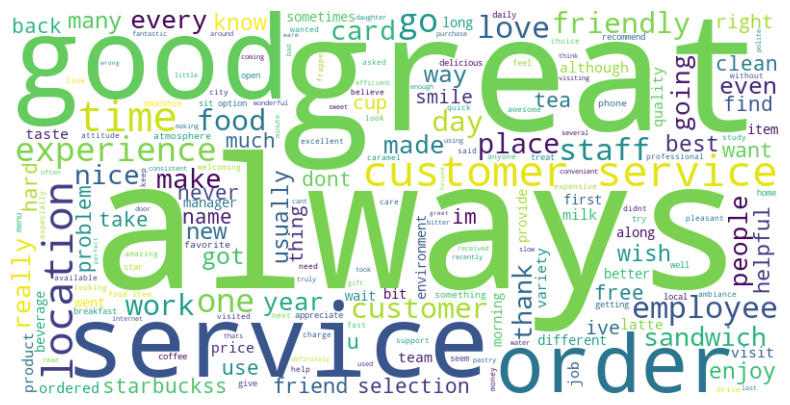

In [8]:
# Define a function to create a word cloud from text
df=data.copy()

def create_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

# Filter positive and negative reviews based on ratings : >3 is +ve and 3 is -ve
positive_reviews = df[df['Rating']>3]['Cleaned_Review_wordcloud'].str.cat(sep=' ')
negative_reviews = df[df['Rating']<3]['Cleaned_Review_wordcloud'].str.cat(sep=' ')

# Create word clouds for positive and negative reviews
print("Word Cloud for Positive Reviews:")
create_wordcloud(positive_reviews)

Word Cloud for Negative Reviews:


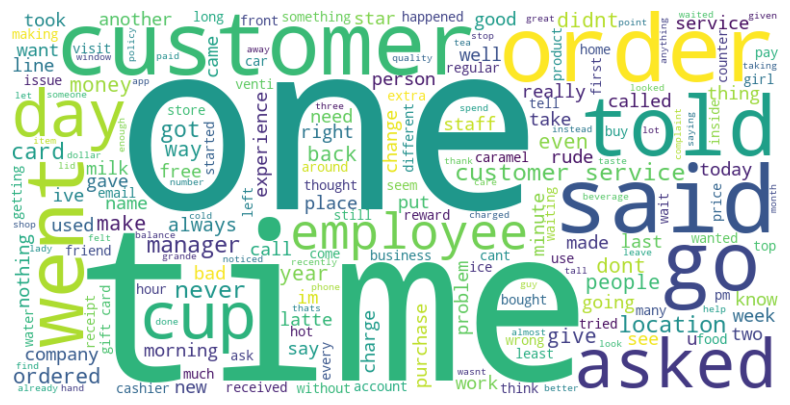

In [9]:
print("Word Cloud for Negative Reviews:")
create_wordcloud(negative_reviews)

### 3) Calculating Sentiment Scores 

The NLTK (Natural Language Toolkit) package provides a sentiment analysis tool called SentimentIntensityAnalyzer that uses a pre-trained lexicon-based approach to calculate sentiment scores for text. When you use the polarity_scores function from this analyzer, it computes four sentiment scores for a given text:

Positive Score: This score represents the relative strength of positive sentiment in the text. Higher values indicate a more positive sentiment.

Negative Score: This score represents the relative strength of negative sentiment in the text. Higher values indicate a more negative sentiment.

Neutral Score: This score represents the relative strength of neutral sentiment in the text. Higher values suggest a more neutral sentiment.

Compound Score: The compound score is a single, aggregated score that combines the positive, negative, and neutral scores into one. It represents the overall sentiment of the text and takes both the intensity and polarity of the sentiment into account. The compound score ranges from -1 (most negative) to 1 (most positive), with 0 indicating a neutral sentiment.

In [10]:
data['Sentiment_scores'] = data['Cleaned_Review'].apply(lambda x: sid.polarity_scores(x))
data.head()

,name,location,Date,Rating,Review,Cleaned_Review_wordcloud,Cleaned_Review,Sentiment_scores
0,Helen,"Wichita Falls, TX","Sept 13, 2023",5,Amber and LaDonna at the Starbucks on Southwes...,amber ladonna southwest parkway always warm we...,amber and ladonna at the on southwest parkway ...,"{'neg': 0.0, 'neu': 0.794, 'pos': 0.206, 'comp..."
1,Courtney,"Apopka, FL","July 16, 2023",5,** at the Starbucks by the fire station on 436...,fire station altamonte spring fl made day fina...,at the by the fire station on in altamonte spr...,"{'neg': 0.107, 'neu': 0.737, 'pos': 0.156, 'co..."
2,Daynelle,"Cranberry Twp, PA","July 5, 2023",5,I just wanted to go out of my way to recognize...,wanted go way recognize employee billy frankli...,i just wanted to go out of my way to recognize...,"{'neg': 0.09, 'neu': 0.761, 'pos': 0.149, 'com..."
3,Taylor,"Seattle, WA","May 26, 2023",5,Me and my friend were at Starbucks and my card...,friend card didnt work thankful worker paid ni...,me and my friend were at and my card didnt wor...,"{'neg': 0.09, 'neu': 0.675, 'pos': 0.234, 'com..."
4,Tenessa,"Gresham, OR","Jan 22, 2023",5,I’m on this kick of drinking 5 cups of warm wa...,im kick drinking cup warm water work instacart...,im on this kick of drinking cups of warm water...,"{'neg': 0.0, 'neu': 0.651, 'pos': 0.349, 'comp..."


### Separating Sentiment Scores into Positive, Negative, Neutral, and Compound Scores

In [11]:
# Create Separate Columns for Positive, Negative, and Neutral Scores
data['Positive_Score'] = data['Sentiment_scores'].apply(lambda x: x['pos'])
data['Negative_Score'] = data['Sentiment_scores'].apply(lambda x: x['neg'])
data['Neutral_Score'] = data['Sentiment_scores'].apply(lambda x: x['neu'])
data['Compound_Score'] = data['Sentiment_scores'].apply(lambda x: x['compound'])

data.head()

,name,location,Date,Rating,Review,Cleaned_Review_wordcloud,Cleaned_Review,Sentiment_scores,Positive_Score,Negative_Score,Neutral_Score,Compound_Score
0,Helen,"Wichita Falls, TX","Sept 13, 2023",5,Amber and LaDonna at the Starbucks on Southwes...,amber ladonna southwest parkway always warm we...,amber and ladonna at the on southwest parkway ...,"{'neg': 0.0, 'neu': 0.794, 'pos': 0.206, 'comp...",0.206,0.000,0.794,0.8991
1,Courtney,"Apopka, FL","July 16, 2023",5,** at the Starbucks by the fire station on 436...,fire station altamonte spring fl made day fina...,at the by the fire station on in altamonte spr...,"{'neg': 0.107, 'neu': 0.737, 'pos': 0.156, 'co...",0.156,0.107,0.737,0.7766
2,Daynelle,"Cranberry Twp, PA","July 5, 2023",5,I just wanted to go out of my way to recognize...,wanted go way recognize employee billy frankli...,i just wanted to go out of my way to recognize...,"{'neg': 0.09, 'neu': 0.761, 'pos': 0.149, 'com...",0.149,0.090,0.761,0.5242
3,Taylor,"Seattle, WA","May 26, 2023",5,Me and my friend were at Starbucks and my card...,friend card didnt work thankful worker paid ni...,me and my friend were at and my card didnt wor...,"{'neg': 0.09, 'neu': 0.675, 'pos': 0.234, 'com...",0.234,0.090,0.675,0.9232
4,Tenessa,"Gresham, OR","Jan 22, 2023",5,I’m on this kick of drinking 5 cups of warm wa...,im kick drinking cup warm water work instacart...,im on this kick of drinking cups of warm water...,"{'neg': 0.0, 'neu': 0.651, 'pos': 0.349, 'comp...",0.349,0.000,0.651,0.9799


### Visualizing Mean Positive and Negative Scores by Rating

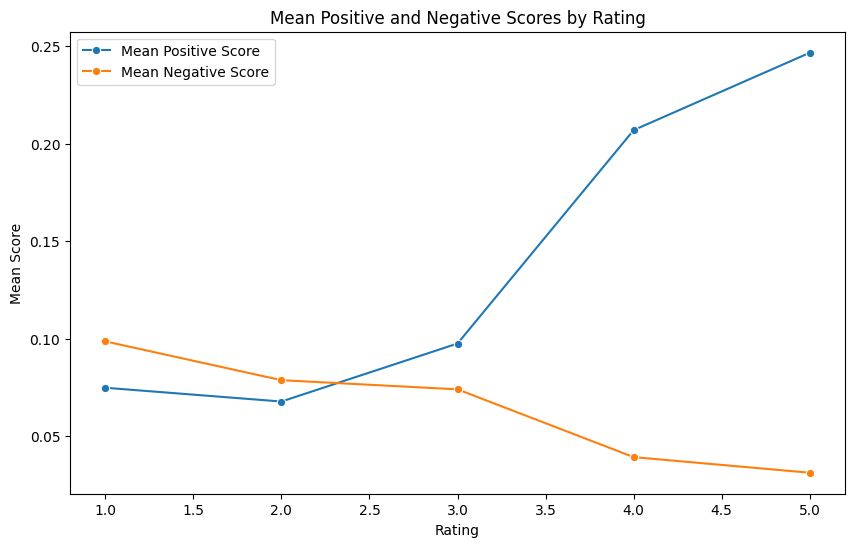

In [12]:
df=data.copy()

# Group by 'Rating' and calculate the mean of 'Positive_Score' and 'Negative_Score'
mean_positive_score = df.groupby('Rating')['Positive_Score'].mean().reset_index()
mean_negative_score = df.groupby('Rating')['Negative_Score'].mean().reset_index()

# Create a Seaborn line plot for Positive_Score
plt.figure(figsize=(10, 6))
sns.lineplot(x='Rating', y='Positive_Score', data=mean_positive_score, label='Mean Positive Score', marker='o')
sns.lineplot(x='Rating', y='Negative_Score', data=mean_negative_score, label='Mean Negative Score', marker='o')
plt.title('Mean Positive and Negative Scores by Rating')
plt.xlabel('Rating')
plt.ylabel('Mean Score')
plt.legend()
plt.show()

#### Observations :
- As the rating increases from 1 to 5, there is a noticeable trend of increasing positive sentiment scores, indicating that higher ratings are associated with more positive sentiments in the data and at the same time The data shows a clear trend of decreasing negative sentiment scores as the rating increases from 1 to 5. This suggests that higher ratings are associated with lower levels of negative sentiment in the dataset.


### Analyzing Sentiment Trends (Compound Score) Over Recent Years

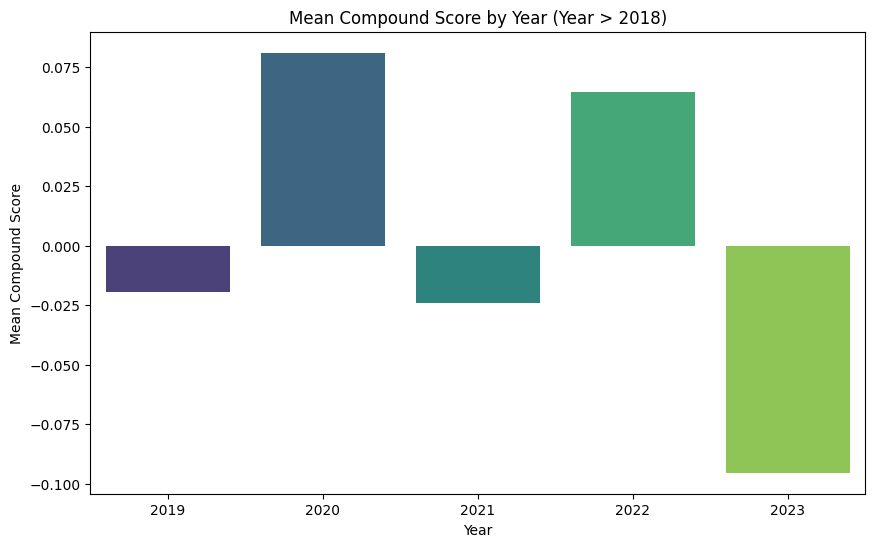

In [13]:
data['Year'] = data['Date'].str.split(", ").str[-1]
data['Year'] = pd.to_numeric(data['Year'], errors='coerce', downcast='integer')

recentdata = data[data['Year']>2018]
mean_scores_by_year = recentdata.groupby('Year')['Compound_Score'].mean().reset_index()

# Create a Seaborn bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Compound_Score', data=mean_scores_by_year, palette='viridis')
plt.title('Mean Compound Score by Year (Year > 2018)')
plt.xlabel('Year')
plt.ylabel('Mean Compound Score')
plt.show()

#### Observations :
- There is some variation in the compound sentiment scores across the years, with 2020 showing the highest mean compound score and 2023 showing the lowest. This indicates potential fluctuations in sentiment in different years.